Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Recesión 70-81 ignorado (fuera de rango)
Ciclo Crisis 82-84 ignorado (fuera de rango)


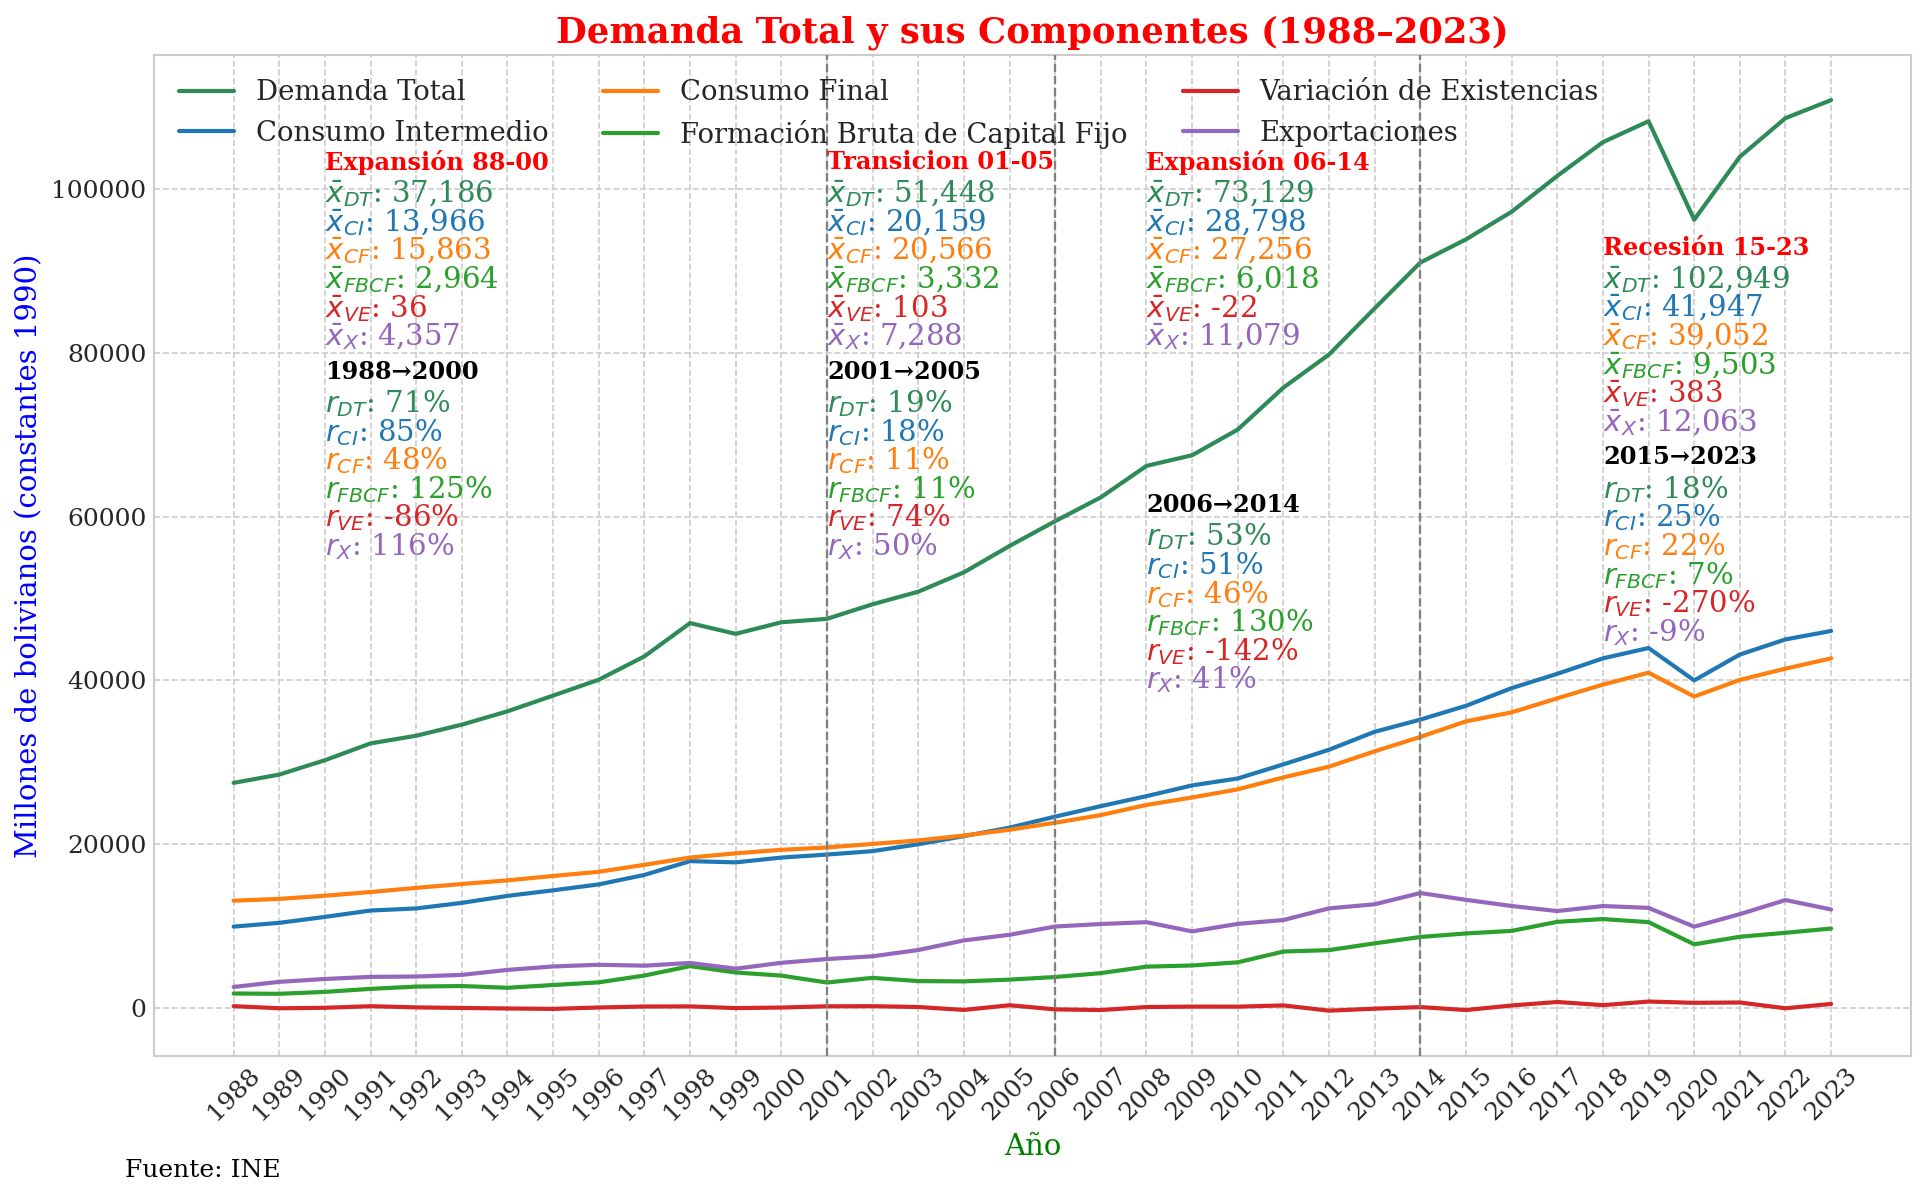

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/demanda_total/demanda_total_componentes.png


In [14]:
# ───────────────────────────── IMPORTS Y CONFIGURACIÓN ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from func_auxiliares.graficos_utils import (
    set_style, init_base_plot, add_hitos, add_cycle_means_multi,
    add_year_value_annotations, add_period_growth_annotations_multi,
    adjust_annot_years, adjust_cycles, adjust_periods
)
from func_auxiliares.config import (
    DB_PATH, CYCLES, ASSETS_DIR, annot_years, periodos_tasas, hitos_v
) 

# Configuración general
output_dir = ASSETS_DIR / "serie_completa" / "demanda_total"
os.makedirs(output_dir, exist_ok=True)
set_style()

# ───────────────────────── CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = pd.read_sql("SELECT * FROM demanda_total", conn, index_col="año").sort_index()

# Convertir miles a millones para mejor legibilidad
valor_cols = ['demanda_total', 'consumo_intermedio', 'consumo_final', 'fbcf', 
              'variacion_existencias', 'exportaciones_bienes_serv']
df[valor_cols] = df[valor_cols] / 1000

# ──────────────── COMPONENTES Y PREPARACIÓN ──────────────────────
componentes = [
    ("demanda_total", "Demanda Total"),
    ("consumo_intermedio", "Consumo Intermedio"),
    ("consumo_final", "Consumo Final"),
    ("fbcf", "Formación Bruta de Capital Fijo"),
    ("variacion_existencias", "Variación de Existencias"),
    ("exportaciones_bienes_serv", "Exportaciones"),
]

cols_componentes = [col for col, _ in componentes]

colors = {
    "demanda_total": "#2E8B57",           # Verde oscuro (serie principal)
    "consumo_intermedio": "#1f77b4",      # Azul
    "consumo_final": "#ff7f0e",           # Naranja
    "fbcf": "#2ca02c",                    # Verde
    "variacion_existencias": "#d62728",   # Rojo
    "exportaciones_bienes_serv": "#9467bd", # Púrpura
}

abbr_map = {
    "demanda_total": "DT",
    "consumo_intermedio": "CI",
    "consumo_final": "CF",
    "fbcf": "FBCF",
    "variacion_existencias": "VE",
    "exportaciones_bienes_serv": "X",
}

# ──────────────── PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
annotate_years = adjust_annot_years(df, annot_years)
cycles = adjust_cycles(df, CYCLES)
periods = adjust_periods(df, periodos_tasas)

cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}

# ───────────── OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────
annotation_offsets = {
    # "demanda_total": {
    #     2001: (0, 1500),
    #     2006: (-1.5, 800),
    #     2014: (-3.2, -800),
    # },
    # "consumo_intermedio": {
    #     2001: (0, 800),
    #     2006: (1.2, 400),
    #     2014: (4, 0),
    # },
    # "consumo_final": {
    #     2001: (0, 600),
    #     2006: (0, 700),
    #     2014: (0, 800),
    # },
    # "fbcf": {
    #     2001: (0, 200),
    #     2006: (0, 300),
    #     2014: (0, 400),
    # },
    # "variacion_existencias": {
    #     2001: (0, 50),
    #     2006: (0, 80),
    #     2014: (0, 100),
    # },
    # "exportaciones_bienes_serv": {
    #     2001: (0, 400),
    #     2006: (0, 600),
    #     2014: (0, 800),
    # },
}

hitos_offset = {year: 0.8 for year in hitos_v}

medias_offsets = {
    "Expansión 88-00": (1990, 0.90),
    "Transicion 01-05": (2001, 0.90),
    "Expansión 06-14": (2008, 0.90),
    "Recesión 15-23": (2018, 0.81),
}

tasas_offsets = {
    "1988-2000": (1990, 0.68),
    "2001-2005": (2001, 0.68),
    "2006-2014": (2008, 0.54),
    "2015-2023": (2018, 0.59),
}

# ────────────────────────── GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,
    colors=colors,
    title=f"Demanda Total y sus Componentes ({df.index.min()}–{df.index.max()})",
    xlabel="Año",
    ylabel="Millones de bolivianos (constantes 1990)",
    source_text="Fuente: INE"
)

# ────────────────────── ELEMENTOS GRÁFICOS ADICIONALES ────────────
add_hitos(ax, df.index, hitos_v, hitos_offset)

add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.4
)
y_max = ax.get_ylim()[1]
line_spacing = y_max * 0.03
add_cycle_means_multi(
    ax, cycle_stats, 
    medias_offsets, 
    abbr_map, colors, 
    line_spacing=line_spacing
)

add_period_growth_annotations_multi(
    ax, df, periods, cols_componentes, tasas_offsets, colors, abbr_map
)

# ────────────────────────── FINALIZACIÓN ──────────────────────────
plt.tight_layout()
filename_base = f"{output_dir}/demanda_total_componentes"
fig.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado en: {filename_base}.png")